## Seismic Analysis of Buried Pipelines

In [368]:
cd /Users/Ram/Dropbox/PyBackUp/Pipeline/

/Users/Ram/Dropbox/PyBackUp/Pipeline


In [369]:
import numpy as np
import pandas as pd
from scipy.spatial import distance
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import sd
from sd.dist import Distance
from scipy.stats import expon, lognorm
from sd.plot import plot_fragility_curve

In [370]:
import fiona

In [371]:
import ipyleaflet
from ipyleaflet import Marker
from ipyleaflet import Map

In [372]:
from pyproj import Proj
from pyproj import Proj, transform

In [373]:
np.random.seed(100000)

### Data import

In [374]:
# read node and link positions
node = pd.read_csv('node_demo.csv')
# link = pd.read_csv('edge classify.csv')
link = pd.read_csv('pipe_demo.csv')

In [375]:
#Transform from Arc1950 to WGS84
inProj = Proj(init='epsg:4326')
outProj = Proj(init='epsg:3395')
x1,y1 = (-122.1044098,38.2789683)
ex,ey = transform(inProj,outProj,x1,y1)
ex,ey

(-13592600.722549204, 4592436.47339457)

### Define Earthquake Epicenter:

In [376]:
# Define expicenter coordinates (check with above command)
ex=-13592600.722549204;
#this is longitude of the epicenter
ey=4592436.47339457; #this is latitude of the epicenter
M=7 # Richter Magnitude

### Transform coordinates to utm

In [377]:
# trasforming latlong into mercetor coordinates
def tran(data):    
    utmxy = {}
    rx=[]
    ry=[]
    for index, row in data.iterrows():
        x = row['x']
        y = row['y']
        inProj = Proj(init='epsg:4326')
        outProj = Proj(init='epsg:3395')
        cz = transform(inProj,outProj,x,y)
#         utmxy[int(row['id'])]=(c,z)
        r1=cz[0]
        r2=cz[1]
        rx.append(r1)
        ry.append(r2)
    rx=np.array(rx)
    ry=np.array(ry)
    return rx,ry

In [378]:
rx,ry=tran(node)

In [379]:
node_id = list(node.id)
rx = list(rx)
ry = list(ry)
typ = list(node.type)
dn1 = {'id':node_id,'x':rx,'y':ry,'type':typ}
df1=pd.DataFrame(dn1)
# df1.set_index('id');

### Distance Check and Measure Length of  Links

In [380]:
# check the distance between two different points
L1=df1.x[3],df1.y[3]
L2=df1.x[5],df1.y[5]
dist = distance.euclidean(L1, L2)
print(dist/1000, "km")

14.298549230891647 km


In [381]:
# data1 and data2 should be node and link, respectively
def Length(data1,data2):  
    dist=[]
    for index, row in data2.iterrows():
        sp=data1[data1.id==row['start_node']]
        start_x, start_y = (list(sp.x),list(sp.y))
        ep=data1[data1.id==row['end_node']]
        end_x,end_y=(list(ep.x),list(ep.y))
        lal = distance.euclidean((start_x, start_y),(end_x,end_y))
        dist.append(lal)
    dist=np.array(dist)
    return dist

In [382]:
link['link_m']=list(Length(node,link))

### Classify and plot various components

In [383]:
# node types
a = node[node['type']==1]
b = node[node['type']==2]
c = node[node['type']==3]

In [384]:
# pipe types
p1 = link[link['type']==1]
p2 = link[link['type']==2]

In [385]:
# calculate distances,intensity from epicenter
r1, pga1, pgv1, pos1 = Distance.com_pga_dist(a,ex,ey,M)
r2, pga2, pgv2, pos2 = Distance.com_pga_dist(b,ex,ey,M)
r3, pga3, pgv3, pos3 = Distance.com_pga_dist(c,ex,ey,M)

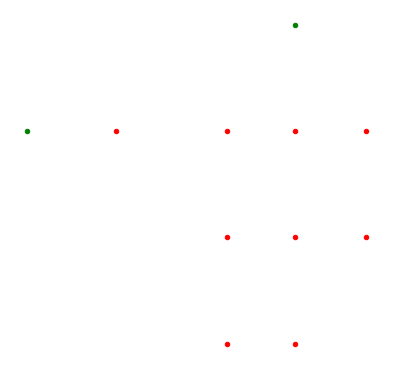

In [386]:
# plot graps with various components
G1=nx.Graph()
G1.add_nodes_from(pos1)
G2=nx.Graph()
G2.add_nodes_from(pos2)
G3=nx.Graph()
G3.add_nodes_from(pos3)
nx.draw(G1,pos1,node_size=20,node_color='r',with_labels=False)
nx.draw(G2,pos2,node_size=20,node_color='b',with_labels=False)
nx.draw(G3,pos3,node_size=20,node_color='g',with_labels=False)

In [387]:
r, pga, pgv, pos = Distance.com_pga_dist(node,ex,ey,M)

In [388]:
d1 = []
for index, row in p1.iterrows():
    stt = str(row['start_node'])+str(row['end_node']).rjust(10)
    d1.append(stt)
d2 = []
for index, row in p2.iterrows():
    stt = str(row['start_node'])+str(row['end_node']).rjust(10)
    d2.append(stt)

/Users/Ram/anaconda3/lib/python3.7/site-packages/networkx/drawing/nx_pylab.py:563: MatplotlibDeprecationWarning: 
The iterable function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use np.iterable instead.
  if not cb.iterable(width):
/Users/Ram/anaconda3/lib/python3.7/site-packages/networkx/drawing/nx_pylab.py:611: MatplotlibDeprecationWarning: 
The is_numlike function was deprecated in Matplotlib 3.0 and will be removed in 3.2. Use isinstance(..., numbers.Number) instead.
  if cb.is_numlike(alpha):


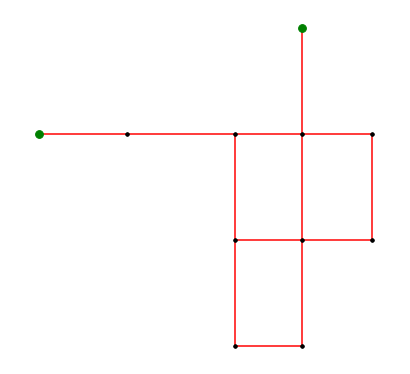

In [389]:
# draw Graph of water network
G4 = nx.parse_edgelist(d1,nodetype=int)
G5 = nx.parse_edgelist(d2,nodetype=int)
nx.draw(G4,pos,node_size=10, node_color='k', edge_color='r',width=1.5)
nx.draw(G5,pos,node_size=10, node_color='k', edge_color='b',width=1.5)
nx.draw(G1,pos1,node_size=10,node_color='k',with_labels=False)
nx.draw(G2,pos2,node_size=10,node_color='k',with_labels=False)
nx.draw(G3,pos3,node_size=60,node_color='g',with_labels=False)
plt.savefig('Fairfield_Network.png', dpi = 600,bbox_inches='tight')

### PGA for nodes

In [390]:
d = []
for index, row in link.iterrows():
    stt = str(row['start_node'])+str(row['end_node']).rjust(10)
    d.append(stt)

In [391]:
r, pga, pgv, pos = Distance.com_pga_dist(node,ex,ey,M)

In [392]:
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))

In [393]:
node_list = list(G.nodes)
pf = {'node_list':node_list}
n_list=pd.DataFrame(pf)

In [394]:
# n_list.tail(1)

In [395]:
node_pga = list(pga)
node_pgv = list(pgv)
ind= list(pos)
pf = {'node_pga':node_pga,'node_pgv':node_pgv,'pid':ind}
n_int=pd.DataFrame(pf)
# n_int.set_index('pid',inplace=True)

In [396]:
# n_int.tail(1)

In [397]:
n_out=n_list.merge(n_int, left_on='node_list', right_on='pid')
n_out.tail(1)

,node_list,node_pga,node_pgv,pid
10,9,0.000254,0.000009,9


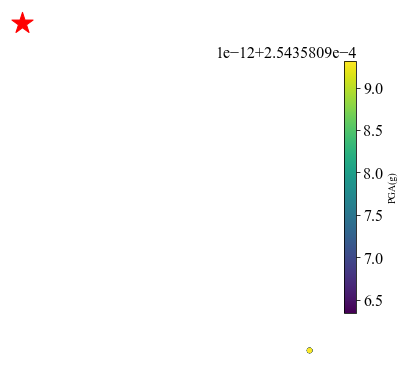

In [398]:
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))
# jet=plt.cm.jet
nx.draw(G,pos,node_size=20,edge_color = 'k',node_color=n_out.node_pga,width=0.5,with_labels=False)
sm = plt.cm.ScalarMappable(norm=plt.Normalize(n_out.node_pga.min(), n_out.node_pga.max()))
plt.colorbar(sm,label='PGA(g)',shrink=0.7)
plt.scatter(ex, ey, s=500, c='r', marker='*', zorder=2)
plt.savefig('Fairfield_Node_PGA.png', dpi = 600,bbox_inches='tight')

In [399]:
Min, Mean, Max={n_out.node_pga.min(),n_out.node_pga.mean(), n_out.node_pga.max()}
Min, Mean, Max

(0.00025435809634610497, 0.00025435809931630225, 0.0002543580976238554)

### PGV for nodes

In [400]:
#convert pgv(m/s) to pgv(in/s)
node_pgv=n_out.node_pgv*100

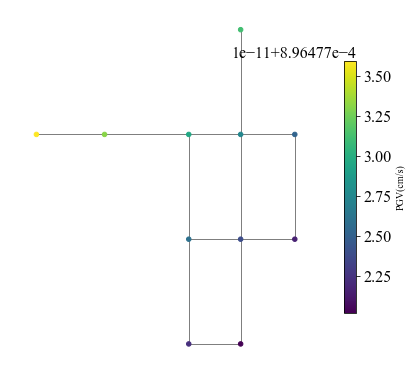

In [401]:
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))
# jet=plt.cm.jet
nx.draw(G,pos,node_size=20,edge_color = 'k',node_color=node_pgv,width=0.5,with_labels=False)
sm = plt.cm.ScalarMappable(norm=plt.Normalize(node_pgv.min(), node_pgv.max()))
plt.colorbar(sm,label='PGV(cm/s)',shrink=0.7)
# plt.scatter(ex, ey, s=1000, c='r', marker='*', zorder=2)
plt.savefig('Fairfield_Node_PGV.png', dpi = 600,bbox_inches='tight')

### PGA for Pipelines

In [402]:
dp = []
for index, row in link.iterrows():
    stt = str(row['start_node'])+str(row['end_node']).rjust(10)+str(row['PipID']).rjust(10)
    dp.append(stt)

In [403]:
# calculate intensity for links
pga_link1, pgv_link1 = Distance.pga_for_link(p1,node,ex,ey,M)
pga_link2, pgv_link2 = Distance.pga_for_link(p2,node,ex,ey,M)

In [404]:
p1_id = list(p1.PipID)
pga_link1 = list(pga_link1)
pgv_link1 = list(pgv_link1)
pf = {'Id':p1_id,'pga_link1':pga_link1,'pgv_link1':pgv_link1}
pipe_1=pd.DataFrame(pf)
pipe_1.set_index('Id',inplace=True);

In [405]:
p2_id = list(p2.PipID)
pga_link2 = list(pga_link2)
pgv_link2 = list(pgv_link2)
pf = {'Id':p2_id,'pga_link2':pga_link2,'pgv_link2':pgv_link2}
pipe_2=pd.DataFrame(pf)
pipe_2.set_index('Id',inplace=True);

In [406]:
p_pga=pipe_1.pga_link1.append(pipe_2.pga_link2)
p_pgv=pipe_1.pgv_link1.append(pipe_2.pgv_link2)

In [407]:
pipe_id=list(p_pga.index)
link_pga=list(p_pga)
link_pgv=list(p_pgv)
pf = {'Id':pipe_id,'link_pga':link_pga,'link_pgv':link_pgv}
pipe=pd.DataFrame(pf)

In [408]:
G = nx.parse_edgelist(dp, nodetype = int, data=(('id',int),))
edges= nx.get_edge_attributes(G,'id')

In [409]:
edge_list=list(edges.values())

In [410]:
pk = {'el':edge_list}
edges=pd.DataFrame(pk)
edges.head(2)

,el
0,119
1,141


In [411]:
p_out=edges.merge(pipe, left_on='el', right_on='Id')
p_out.head(2)

,el,Id,link_pga,link_pgv
0,119,119.0,0.000255,0.000009
1,141,141.0,0.000255,0.000009


In [412]:
pipe_pga=p_out.link_pga

/Users/Ram/anaconda3/lib/python3.7/site-packages/networkx/drawing/nx_pylab.py:569: MatplotlibDeprecationWarning: 
The iterable function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use np.iterable instead.
  and cb.iterable(edge_color) \
/Users/Ram/anaconda3/lib/python3.7/site-packages/networkx/drawing/nx_pylab.py:579: MatplotlibDeprecationWarning: 
The iterable function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use np.iterable instead.
  for c in edge_color]):


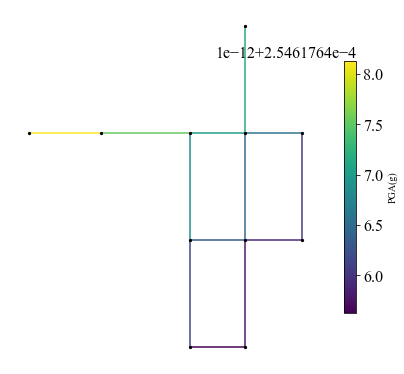

In [413]:
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))
jet=plt.cm.jet
nx.draw(G,pos,node_size=5,edge_color =pipe_pga, node_color='k',width=1.5,with_labels=False)
sm = plt.cm.ScalarMappable(norm=plt.Normalize(pipe_pga.min(), pipe_pga.max()))
plt.colorbar(sm,label='PGA(g)',shrink=0.7)
# plt.scatter(ex, ey, s=1000, c='r', marker='*', zorder=2)
plt.savefig('Fairfield_Link_PGA.png', dpi = 600,bbox_inches='tight')

### PGV for Pipelines

In [414]:
pipe_pgv=p_out.link_pgv*39.3701

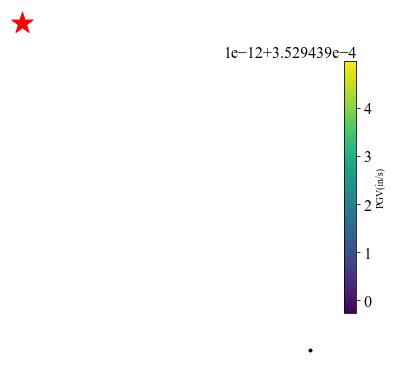

In [415]:
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))
jet=plt.cm.jet
nx.draw(G,pos,node_size=5,edge_color =pipe_pgv, node_color='k',width=1.5,with_labels=False)
sm = plt.cm.ScalarMappable(norm=plt.Normalize(pipe_pgv.min(), pipe_pgv.max()))
plt.colorbar(sm,label='PGV(in/s)',shrink=0.7)
plt.scatter(ex, ey, s=500, c='r', marker='*', zorder=2)
plt.savefig('Fairfield_Link_PGV.png', dpi = 600,bbox_inches='tight')

In [416]:
Min, Mean, Max={pipe_pgv.min(),pipe_pgv.mean(), pipe_pgv.max()}
Min, Mean, Max

(0.0003529439049777526, 0.00035294390174134206, 0.0003529438997439647)

### ALA Repair Rates

In [417]:
r_rate=0.00187*pipe_pgv

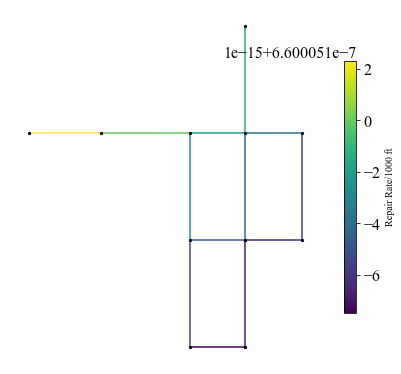

In [418]:
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))
jet=plt.cm.jet
nx.draw(G,pos,node_size=5,edge_color =r_rate, node_color='k',width=1.5,with_labels=False)
sm = plt.cm.ScalarMappable(norm=plt.Normalize(r_rate.min(), r_rate.max()))
plt.colorbar(sm,label='Repair Rate/1000 ft',shrink=0.7)
# plt.scatter(ex, ey, s=1000, c='r', marker='*', zorder=2)
plt.savefig('Fairfield_repair_rate.png', dpi = 600,bbox_inches='tight')

In [419]:
value=r_rate
Min, Mean, Max={value.min(),value.mean(), value.max()}
Min, Mean, Max

(6.600050962563097e-07, 6.60005092521214e-07, 6.600051023083973e-07)

Label Plot

In [420]:
d = []
for index, row in link.iterrows():
    stt = str(row['start_node'])+str(row['end_node']).rjust(10)+str(row['PipID']).rjust(10)
    d.append(stt)

In [421]:
d = []
for index, row in link.iterrows():
    stt = str(row['start_node'])+str(row['end_node']).rjust(10)+str(row['PipID']).rjust(10)
#     stt = str(row['start node'])+str(row['end node']).rjust(10)
    d.append(stt)

In [422]:
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))

In [423]:
edges= nx.get_edge_attributes(G,'id')

In [424]:
uu=edges.values()
el = list(uu)
# dl= list(fi)
# kl= list(zi)
pk = {'el':el}
T4=pd.DataFrame(pk)

In [425]:
T4.tail(1)

,el
12,125


In [426]:
T4.shape

(13, 1)

In [427]:
mk = list(pga)
ind= list(pos)
pk = {'ds':mk,'pid':ind}
T1=pd.DataFrame(pk)
# nP.set_index('lp1',inplace=True)

In [428]:
dam=T4.merge(T1, left_on='el', right_on='pid')
dam.tail(1)

,el,ds,pid


In [429]:
dam.shape

(0, 3)

In [430]:
# plt.rcParams['figure.figsize'] = [14, 8]
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))
# G = nx.parse_edgelist(d,nodetype=int)
jet=plt.cm.jet
# nx.draw(G,pos,node_size=20,edge_color = T4.el,node_color='k',width=1.5,with_labels=False)
# edge_labels = nx.get_edge_attributes(G, 'id')
# nx.draw_networkx_edge_labels(G,pos,edge_labels=edge_labels,label_pos=0.5,alpha=1.0,font_size=8, font_color='k')
# sm = plt.cm.ScalarMappable(norm=plt.Normalize(0, 4))
# plt.colorbar(sm,label='label',shrink=0.5)
# plt.scatter(ex, ey, s=1000, c='r', marker='*', zorder=2)
# plt.savefig('Fairfield_edge_label.png', dpi = 600,bbox_inches='tight')

### Correction Factors

In [431]:
pipe_characteristics = pd.read_csv('pipe_demo.csv',dtype={'index':str})

In [432]:
pipe_characteristics.set_index('PipID',inplace=True)

In [433]:
pipe_characteristics.head(2)

,start_node,end_node,type,Length,dia,M_type,Material,soil_type,age
PipID,,,,,,,,,
119,10,11,1,570,24,CI,CIP,L,1920
121,11,12,1,240,16,CI,CIP,L,1920


In [434]:
C=sd.cf.correction_factor(pipe_characteristics)

In [435]:
link_id=list(C.index)
link_C=list(C)
pf = {'Id':pipe_id,'C':link_C}
c_list=pd.DataFrame(pf)
c_list.tail(2)

,Id,C
11,139.0,2.0
12,141.0,2.0


In [436]:
G = nx.parse_edgelist(dp, nodetype = int, data=(('id',int),))
edges= nx.get_edge_attributes(G,'id')
edge_list=list(edges.values())
pk = {'el':edge_list}
c_adj=pd.DataFrame(pk)
c_adj.tail(2)

,el
11,139
12,125


In [437]:
c_fact=c_adj.merge(c_list, left_on='el', right_on='Id')

In [438]:
c_fact.tail(2)

,el,Id,C
11,139,139.0,2.0
12,125,125.0,1.0


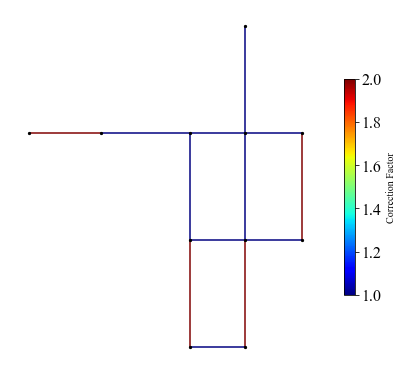

In [439]:
c_color=plt.cm.jet
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))
nx.draw(G,pos,node_size=5,edge_color =c_fact.C, node_color='k',width=1.5,with_labels=False,edge_cmap = c_color)
sm = plt.cm.ScalarMappable(norm=plt.Normalize(c_fact.C.min(), c_fact.C.max()),cmap = c_color)
plt.colorbar(sm,label='Correction Factor',shrink=0.6)
# plt.scatter(ex, ey, s=1000, c='r', marker='*', zorder=2)
plt.savefig('Fairfield_Correc_Factor.png', dpi = 600,bbox_inches='tight')

### Table_Merged

In [440]:
nn=c_adj.merge(link, left_on='el', right_on='PipID')

In [441]:
rkk=nn.merge(p_out, left_on='el', right_on='Id')

In [442]:
out=rkk.merge(c_fact, left_on='el_x', right_on='el')

In [443]:
out.head(2)

,el_x,start_node,end_node,type,PipID,Length,dia,M_type,Material,soil_type,age,link_m,el_y,Id_x,link_pga,link_pgv,el,Id_y,C
0,119,10,11,1,119,570,24,CI,CIP,L,1920,0.032122,119,119.0,0.000255,0.000009,119,119.0,1.0
1,141,9,10,1,141,190,24,CI,CIP,M,1920,0.026001,141,141.0,0.000255,0.000009,141,141.0,2.0


In [444]:
out.Length.sum()

3555

In [445]:
out.link_m.sum()/1000

0.0007588421000000238

In [446]:
out.link_m.min()/100

0.00019797600000003967

In [447]:
out.C.min()

1.0

In [448]:
out.link_pgv.min()

8.964770212520789e-06

In [449]:
out.link_m.min()*out.C.min()*out.link_pgv.min()/1000

1.7748093475943713e-10

### Modified Repair Rate (per 1000 ft) considering Correction Factors

In [450]:
Mod_RR=0.00187*out.link_pgv*39.3701*out.C

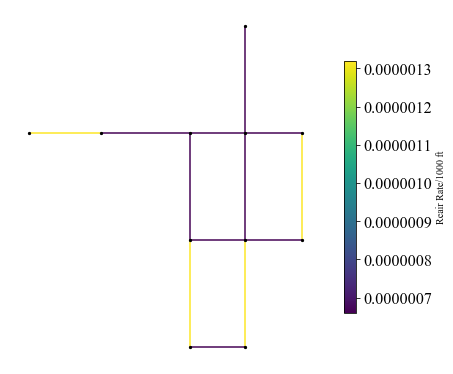

In [451]:
edge_value=Mod_RR
c_color=plt.cm.jet
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))
nx.draw(G,pos,node_size=5,edge_color =edge_value, node_color='k',width=1.5,with_labels=False)
sm = plt.cm.ScalarMappable(norm=plt.Normalize(edge_value.min(), edge_value.max()))
plt.colorbar(sm,label='Reair Rate/1000 ft',shrink=0.7)
# plt.scatter(ex, ey, s=1000, c='r', marker='*', zorder=2)
plt.savefig('Fairfield_Mod_RR.png', dpi = 600,bbox_inches='tight')

In [452]:
Min, Mean, Max={Mod_RR.min(),Mod_RR.mean(), Mod_RR.max()}

In [453]:
Min, Mean, Max

(8.63083587346726e-07, 6.60005092521214e-07, 1.3200102046167946e-06)

### New Control Variable (Θ)

In [454]:
C_PGV_L=(out.C)*(out.link_pgv*39.3701)*(out.link_m*3.28084/1000)

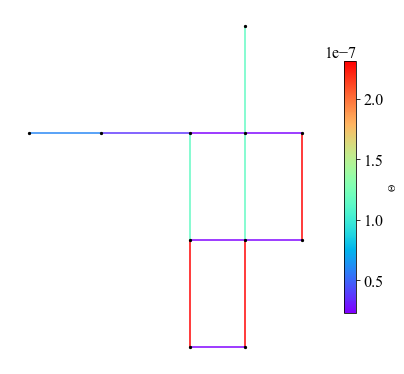

In [455]:
edge_value=C_PGV_L
c_color=plt.cm.rainbow
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))
nx.draw(G,pos,node_size=5,edge_color =edge_value, node_color='k',width=1.5,with_labels=False,edge_cmap = c_color)
sm = plt.cm.ScalarMappable(norm=plt.Normalize(edge_value.min(), edge_value.max()),cmap = c_color)
plt.colorbar(sm,label='Θ',shrink=0.7)
# plt.scatter(ex, ey, s=500, c='r', marker='*', zorder=2)
plt.savefig('Fairfield_C_PGV_L.png', dpi = 600,bbox_inches='tight')

In [456]:
Min, Mean, Max={C_PGV_L.min(),C_PGV_L.mean(), C_PGV_L.max()}
Min, Mean, Max

(2.3159049355772994e-07, 9.663053677486164e-08, 2.292467970200349e-08)

### Pipe Age

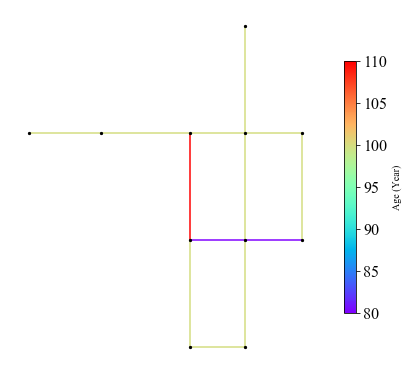

In [457]:
edge_value=2020-out.age
c_color=plt.cm.rainbow
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))
nx.draw(G,pos,node_size=5,edge_color =edge_value, node_color='k',width=1.5,with_labels=False,edge_cmap = c_color)
sm = plt.cm.ScalarMappable(norm=plt.Normalize(edge_value.min(), edge_value.max()),cmap = c_color)
plt.colorbar(sm,label='Age (Year)',shrink=0.7)
# plt.scatter(ex, ey, s=500, c='r', marker='*', zorder=2)
plt.savefig('Fairfield_Age.png', dpi = 600,bbox_inches='tight')

### Probability of Failure

#### Pipe Leak

In [458]:
P_leak=1-np.exp(-0.00187*C_PGV_L)

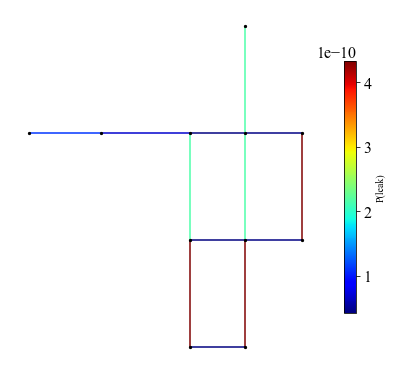

In [459]:
edge_value=P_leak
c_color=plt.cm.jet
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))
nx.draw(G,pos,node_size=5,edge_color =edge_value, node_color='k',width=1.5,with_labels=False,edge_cmap = c_color)
sm = plt.cm.ScalarMappable(norm=plt.Normalize(edge_value.min(), edge_value.max()),cmap = c_color)
plt.colorbar(sm,label='P(leak)',shrink=0.7)
# plt.scatter(ex, ey, s=500, c='r', marker='*', zorder=2)
plt.savefig('Fairfield_P_leak.png', dpi = 600,bbox_inches='tight')

#### Pipe Break

In [460]:
P_break=P_leak*0.25

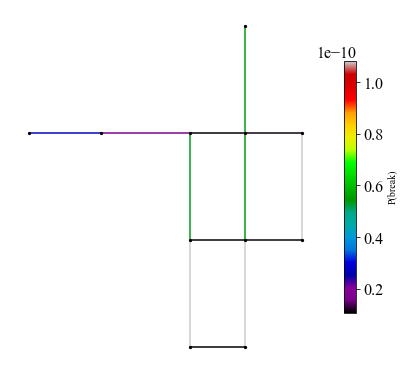

In [461]:
edge_value=P_break
c_color=plt.cm.nipy_spectral
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))
nx.draw(G,pos,node_size=5,edge_color =edge_value, node_color='k',width=1.5,with_labels=False,edge_cmap = c_color)
sm = plt.cm.ScalarMappable(norm=plt.Normalize(edge_value.min(), edge_value.max()),cmap = c_color)
plt.colorbar(sm,label='P(break)',shrink=0.7)
# plt.scatter(ex, ey, s=500, c='r', marker='*', zorder=2)
plt.savefig('Fairfield_P_break.png', dpi = 600,bbox_inches='tight')

# Damage States

### Node damage simulations

In [462]:
np.random.seed(10000)

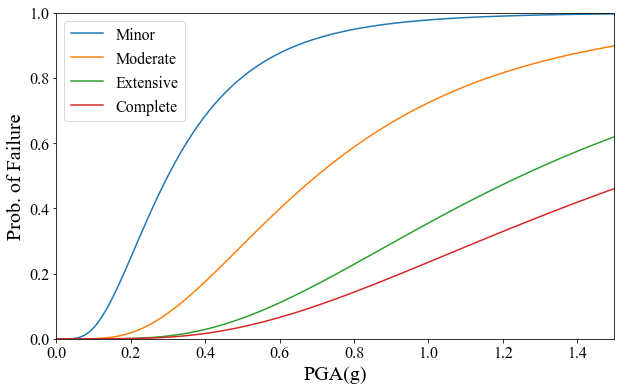

In [463]:
node_FC=sd.FragilityCurve()
node_FC.add_state('Minor', 1, {'Default': lognorm(0.60, scale=0.30)})  
node_FC.add_state('Moderate', 2, {'Default': lognorm(0.60, scale=0.70)})
node_FC.add_state('Extensive', 3, {'Default': lognorm(0.60, scale=1.25)})
node_FC.add_state('Complete', 4, {'Default': lognorm(0.65, scale=1.60)})
plot_fragility_curve(node_FC, xlabel='C∙PGV∙L', ylabel='Prob. of Failure',fill=False,xmax=1.5)
plt.xlabel('PGA(g)',size=20)
plt.ylabel('Prob. of Failure',size=20)
plt.legend(prop={'size':16},loc='upper left')
plt.plot(linewidth=2.0)
plt.rc('font',family='Times New Roman')
plt.rc('xtick', labelsize=16)
plt.rc('ytick', labelsize=16)
plt.grid(False)
plt.savefig('Fragility_Tanks.png', dpi = 600,bbox_inches='tight')

In [464]:
r, pga, pgv, pos = Distance.com_pga_dist(node,ex,ey,M)

In [465]:
node_id = list(node.id)
pga_val = list(pga)
dn1 = {'Id':node_id,'pga1':pga_val}
df1=pd.DataFrame(dn1)
df1.set_index('Id',inplace=True);

In [466]:
df1.head(2)

,pga1
Id,
10,0.000254
11,0.000254


In [467]:
np.random.seed(12345)
node_Pr = node_FC.cdf_probability(df1['pga1'])
node_damage_state = node_FC.sample_damage_state(node_Pr)
node_damage_state_map = node_FC.get_priority_map()
node_damage_val = node_damage_state.map(node_damage_state_map)
node_damage_val.value_counts()

0    11
dtype: int64

In [468]:
node_Pr.tail(2)

,Minor,Moderate,Extensive,Complete
Id,,,,
9,2.25075e-32,4.37778e-40,7.38205e-46,1.40844e-41
2,2.25075e-32,4.37778e-40,7.38205e-46,1.40844e-41


In [469]:
node_damage_val;

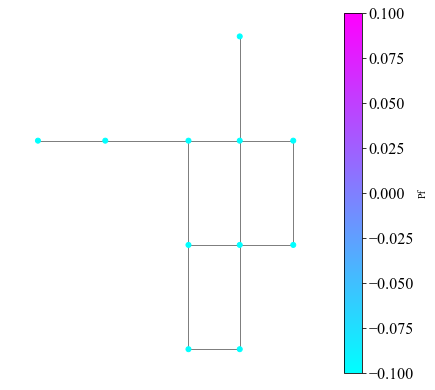

In [470]:
edge_value=node_damage_val
c_color=plt.cm.cool
nx.draw(G,pos,node_size=25,edge_color ='k', node_color=edge_value, width=0.5,with_labels=False,cmap = c_color)
sm = plt.cm.ScalarMappable(norm=plt.Normalize(edge_value.min(), edge_value.max()),cmap = c_color)
plt.colorbar(sm,label='Pf')
plt.savefig('Fairfield_Source_Damage.png', dpi = 600,bbox_inches='tight')

### Pipe damage simulations

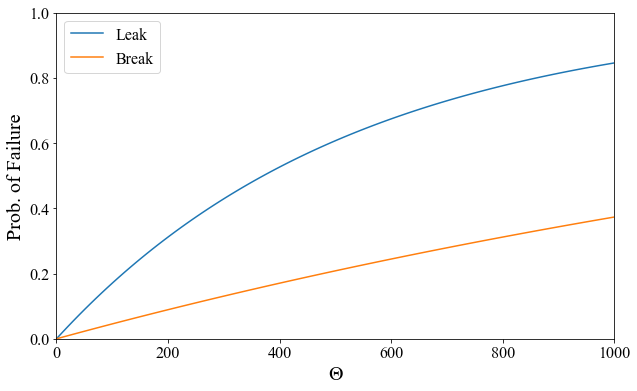

In [471]:
pipe_FC = sd.FragilityCurve()
pipe_FC.add_state('Break', 2, {'Default': expon(scale=1/(0.00187*.25))})
pipe_FC.add_state('Leak', 1, {'Default': expon(scale=1/(0.00187))})
plot_fragility_curve(pipe_FC, xlabel='Θ', ylabel='Prob. of Failure',fill=False,xmax=1000)
plt.xlabel('Θ',size=20)
plt.ylabel('Prob. of Failure',size=20)
plt.legend(prop={'size':16},loc='upper left')
plt.rc('font',family='Times New Roman')
plt.rc('xtick', labelsize=16)
plt.rc('ytick', labelsize=16)
plt.grid(False)
plt.savefig('Fragility.png', dpi = 600,bbox_inches='tight')

In [472]:
pga_link,pgv_link = Distance.pga_for_link(link,node,ex,ey,M)

In [473]:
p11_id = list(link.PipID)
p11_pga=list(pgv_link)
p11_len=list(out.link_m)
CV=list(C_PGV_L)
pk = {'Id':p11_id,'pgv':p11_pga,'len':p11_len,'CV':C_PGV_L}
pip_f=pd.DataFrame(pk)
pip_f.set_index('Id',inplace=True)

In [474]:
pip_f.head()

,pgv,len,CV
Id,,,
119,0.000009,0.032122,3.719540e-08
121,0.000009,0.026001,6.021631e-08
122,0.000009,0.019798,2.292468e-08
123,0.000009,0.100000,1.157952e-07
124,0.000009,0.020663,2.392700e-08


In [475]:
np.random.seed(12345)
pipe_Pr = pipe_FC.cdf_probability(pip_f['CV'])
pipe_damage_state = pipe_FC.sample_damage_state(pipe_Pr)
pipe_damage_state_map = pipe_FC.get_priority_map()
pipe_damage_val = pipe_damage_state.map(pipe_damage_state_map)
pipe_damage_val.value_counts()

0    13
dtype: int64

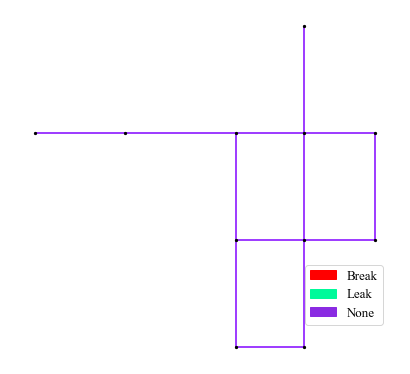

In [476]:
# plt.rcParams['figure.figsize'] = [5.5, 5]
edge_value=pipe_damage_val
c_color=plt.cm.rainbow
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))
nx.draw(G,pos,node_size=5,edge_color =edge_value, node_color='k',width=1.5,with_labels=False,edge_cmap = c_color)
sm = plt.cm.ScalarMappable(norm=plt.Normalize(edge_value.min(), edge_value.max()),cmap = c_color)

red_patch = mpatches.Patch(color='red', label='Break')
cyan_patch = mpatches.Patch(color='mediumspringgreen', label='Leak')
blue_patch = mpatches.Patch(color='blueviolet', label='None')

plt.legend(handles=[red_patch,cyan_patch, blue_patch],loc=10,fontsize=13,bbox_to_anchor=(0.8, 0.0, 0.1, 0.4))
# plt.scatter(ex, ey, s=500, c='r', marker='*', zorder=1)
plt.savefig('Fairfield_Damage_States.png', dpi = 600,bbox_inches='tight')

### Betweenness Centrality

In [477]:
bc_edge=list(nx.edge_betweenness_centrality(G).values())

In [478]:
ebc=pd.Series(bc_edge)

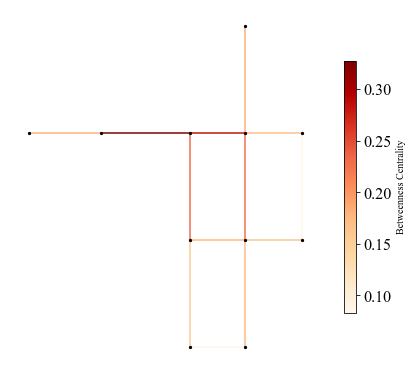

In [479]:
edge_value=ebc
c_color=plt.cm.OrRd
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))
nx.draw(G,pos,node_size=5,edge_color =edge_value, node_color='k',width=1.5,with_labels=False,edge_cmap = c_color)
sm = plt.cm.ScalarMappable(norm=plt.Normalize(edge_value.min(), edge_value.max()),cmap = c_color)
plt.colorbar(sm,label='Betweenness Centrality',shrink=0.7)
# plt.scatter(ex, ey, s=500, c='r', marker='*', zorder=2)
plt.savefig('Fairfield_EBC.png', dpi = 600,bbox_inches='tight')

In [480]:
bc_node=list(nx.betweenness_centrality(G).values())

In [481]:
nbc=pd.Series(bc_node)

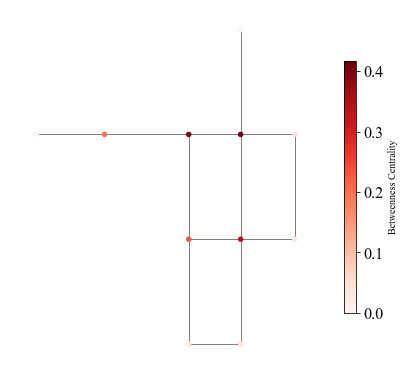

In [482]:
edge_value=nbc
c_color=plt.cm.Reds
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))
nx.draw(G,pos,node_size=20,edge_color ='k', node_color=edge_value,width=.5,with_labels=False,cmap = c_color)
sm = plt.cm.ScalarMappable(norm=plt.Normalize(edge_value.min(), edge_value.max()),cmap = c_color)
plt.colorbar(sm,label='Betweenness Centrality',shrink=0.7)
# plt.scatter(ex, ey, s=500, c='r', marker='*', zorder=2)
plt.savefig('Fairfield_NBC.png', dpi = 600,bbox_inches='tight')

### Normalized EBC

In [483]:
ebc=pd.Series(bc_edge)

In [484]:
norm_ebc=(ebc-ebc.min())/(ebc.max()-ebc.min())

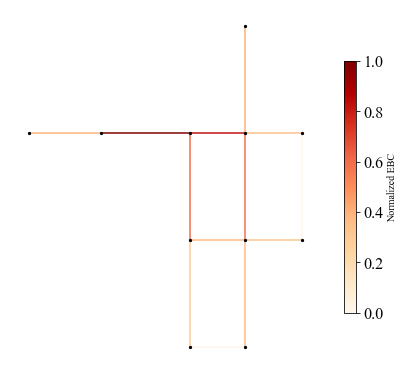

In [485]:
edge_value=norm_ebc
c_color=plt.cm.OrRd
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))
nx.draw(G,pos,node_size=5,edge_color =edge_value, node_color='k',width=1.5,with_labels=False,edge_cmap = c_color)
sm = plt.cm.ScalarMappable(norm=plt.Normalize(edge_value.min(), edge_value.max()),cmap = c_color)
plt.colorbar(sm,label='Normalized EBC',shrink=0.7)
# plt.scatter(ex, ey, s=500, c='r', marker='*', zorder=2)
plt.savefig('Fairfield_Norm_EBC.png', dpi = 600,bbox_inches='tight')

### Condition Index

In [486]:
pc_id = list(link.PipID)
pc_age=list(0.0003*(2020-out.age)**2-0.0003*(2020-out.age)+1)
pk = {'Id':pc_id,'CI':pc_age}
pc_f=pd.DataFrame(pk)
pc_f.set_index('Id',inplace=True)

In [487]:
pc_f.head()

,CI
Id,
119,3.970
121,3.970
122,3.970
123,4.597
124,3.970


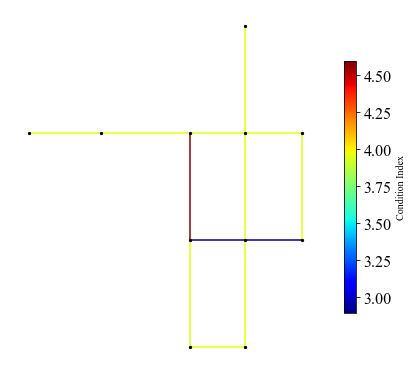

In [488]:
edge_value=pc_f.CI
c_color=plt.cm.jet
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))
nx.draw(G,pos,node_size=5,edge_color =edge_value, node_color='k',width=1.5,with_labels=False,edge_cmap = c_color)
sm = plt.cm.ScalarMappable(norm=plt.Normalize(edge_value.min(), edge_value.max()),cmap = c_color)
plt.colorbar(sm,label='Condition Index',shrink=0.7)
# plt.scatter(ex, ey, s=500, c='r', marker='*', zorder=2)
plt.savefig('Fairfield_CI.png', dpi = 600,bbox_inches='tight')

In [489]:
Min, Mean, Max={pc_f.CI.min(),pc_f.CI.mean(), pc_f.CI.max()}
Min, Mean, Max

(2.896, 3.8529999999999993, 4.5969999999999995)

### Normalized Condition Index

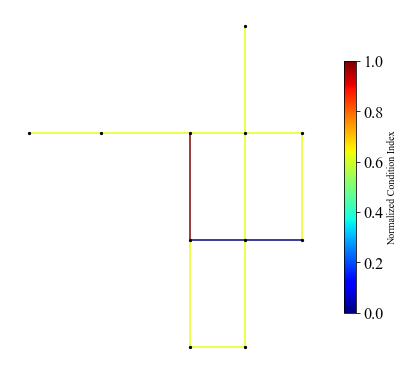

In [490]:
norm_CI=(pc_f.CI-pc_f.CI.min())/(pc_f.CI.max()-pc_f.CI.min())
edge_value=norm_CI
c_color=plt.cm.jet
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))
nx.draw(G,pos,node_size=5,edge_color =edge_value, node_color='k',width=1.5,with_labels=False,edge_cmap = c_color)
sm = plt.cm.ScalarMappable(norm=plt.Normalize(edge_value.min(), edge_value.max()),cmap = c_color)
plt.colorbar(sm,label='Normalized Condition Index',shrink=0.7)
# plt.scatter(ex, ey, s=500, c='r', marker='*', zorder=2)
plt.savefig('Fairfield_Norm_CI.png', dpi = 600,bbox_inches='tight')

### Maintenance Action

In [491]:
pc_id = list(link.PipID)

In [492]:
pc_id = list(link.PipID)
CI=list(norm_CI)
nbc=list(norm_ebc)
pk = {'Id':pc_id,'CI':CI,'nbc':norm_ebc}
cost=pd.DataFrame(pk)
cost.set_index('Id',inplace=True)

In [493]:
cost.head()

,CI,nbc
Id,,
119,0.631393,1.000000
121,0.631393,0.404467
122,0.631393,0.828784
123,1.000000,0.605459
124,0.631393,0.349876


In [494]:
Index=cost.CI*0.7+cost.nbc*0.3

In [495]:
Index=cost.CI*0.7+cost.nbc*0.3
pc_id = list(link.PipID)
ind=list(Index)
dl=list(pipe_damage_val)
pk = {'Id':pc_id,'ind':ind,'dl':dl}
need=pd.DataFrame(pk)
need.set_index('Id',inplace=True)

In [496]:
need.head()

,ind,dl
Id,,
119,0.741975,0
121,0.563315,0
122,0.690611,0
123,0.881638,0
124,0.546938,0


In [497]:
mmm=need[(need.ind>0.5)&(need.dl>0)]

In [498]:
link['link_m']=list(Length(node,link))

In [499]:
need.dl.value_counts()

0    13
Name: dl, dtype: int64

In [500]:
# data1 and data2 should be node and link, respectively
def C_Check(data):  
    maint=[]
    for index,row in data.iterrows():
        if (row['ind']>=0.5) & (row['dl']>0):
            mm=2
        elif (row['ind']<0.5) & (row['dl']>0):
            mm=1
        else:
            mm=0
        maint.append(mm)
    maint=np.array(maint)
    return maint

In [501]:
need['MA']=list(C_Check(need))

In [502]:
need.MA.value_counts()

0    13
Name: MA, dtype: int64

In [503]:
need.head(2)

,ind,dl,MA
Id,,,
119,0.741975,0,0
121,0.563315,0,0


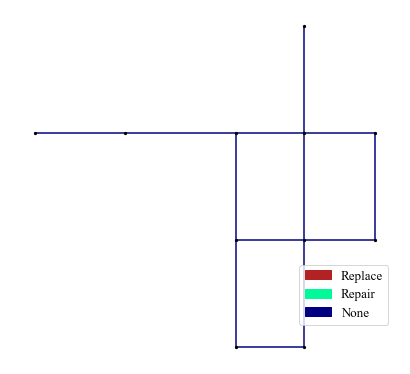

In [504]:
plt.rcParams['figure.figsize'] = [5.5, 5]
edge_value=need.MA
c_color=plt.cm.jet
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))
nx.draw(G,pos,node_size=5,edge_color =edge_value, node_color='k',width=1.5,with_labels=False,edge_cmap = c_color)
sm = plt.cm.ScalarMappable(norm=plt.Normalize(edge_value.min(), edge_value.max()),cmap = c_color)
red_patch = mpatches.Patch(color='firebrick', label='Replace')
cyan_patch = mpatches.Patch(color='mediumspringgreen', label='Repair')
blue_patch = mpatches.Patch(color='navy', label='None')

plt.legend(handles=[red_patch,cyan_patch, blue_patch],loc=10,fontsize=13,bbox_to_anchor=(0.8, 0.0, 0.1, 0.4))
# plt.scatter(ex, ey, s=500, c='r', marker='*', zorder=2)
plt.savefig('Fairfield_MA.png', dpi = 600,bbox_inches='tight')

In [505]:
need[need.MA>=1].to_csv('pipe_repair.csv')

### Repair Cost Estimation

In [506]:
nw=need.merge(out, left_on='Id', right_on='el_x')

In [507]:
nw['NoB']=(0.00187*nw.link_pgv*39.3701*nw.C)*(nw.link_m*3.28084/1000)

In [508]:
nw.NoB;
nw['nNoB']=np.ceil(nw.NoB).astype(int)

In [509]:
def pipe_annual_cost(data,pipe_cost=None):
    """ 
    """
    nrpr = []
    nrpl = []

    network_cost = 0
        
    if pipe_cost is None:
        diameter = [4, 6, 8, 10, 12, 14, 16, 18, 20, 24, 28, 30, 32, 34, 36] # inch
        rpl = [600, 630, 675, 750, 825, 1200, 1950, 2400, 2700, 3450, 4350, 4650, 5250, 5700, 6300] # replace cost/m
        rpr = [400, 420, 450, 500, 550, 800, 1300, 1600, 1800, 2300, 2900, 3100, 3500, 3800, 4200] # repair cost
        
#         diameter = np.array(diameter)*0.0254 # m
        repair_cost = pd.Series(rpr,diameter)        
        replace_cost = pd.Series(rpl,diameter)        

    # Pipe construction cost
    for index, row in data.iterrows():
        dia = row['dia']
        length=row['link_m']
        idxrpr = np.argmin([np.abs(repair_cost.index - dia)])
        idxrpl = np.argmin([np.abs(replace_cost.index - dia)])
        #print(link_name, pipe_cost.iloc[idx], link.length)
        repair_C = network_cost + repair_cost.iloc[idxrpr]
        replace_C = network_cost + replace_cost.iloc[idxrpl]*length
        nrpr.append(repair_C)
        nrpl.append(replace_C)
    nrpr = np.array(nrpr)
    nrpl = np.array(nrpl)

        
    return nrpr,nrpl

In [510]:
xxx,yyy=pipe_annual_cost(nw)

In [511]:
nw['repair_C']=xxx
nw['replace_C']=yyy

In [512]:
def C_Est(data):  
    cost=[]
    for index,row in data.iterrows():
        if (row['MA']==1):
            mm=row['repair_C']*row['nNoB']
        elif (row['MA']==2):
            mm=row['replace_C']
        else:
            mm=0
        cost.append(mm)
    cost=np.array(cost)
    return cost

In [513]:
nw['T_Cost']=list(C_Est(nw))

In [514]:
Cost_for_repair=print(nw[nw.MA==1].T_Cost.sum())

0


In [515]:
Cost_for_replace=print(nw[nw.MA==2].T_Cost.sum())

0


In [516]:
total_maintenace_cost=print(nw.T_Cost.sum())

0


In [517]:
nw.head()

,ind,dl,MA,el_x,start_node,end_node,type,PipID,Length,dia,...,link_pga,link_pgv,el,Id_y,C,NoB,nNoB,repair_C,replace_C,T_Cost
0,0.741975,0,0,119,10,11,1,119,570,24,...,0.000255,0.000009,119,119.0,1.0,6.955540e-11,1,2300,110.819865,0
1,0.563315,0,0,121,11,12,1,121,240,16,...,0.000255,0.000009,121,121.0,1.0,4.286915e-11,1,1300,38.605320,0
2,0.690611,0,0,122,12,13,1,122,440,24,...,0.000255,0.000009,122,122.0,1.0,4.474350e-11,1,2300,71.288040,0
3,0.881638,0,0,123,21,22,1,123,220,16,...,0.000255,0.000009,123,123.0,1.0,4.286915e-11,1,1300,38.605320,0
4,0.546938,0,0,124,22,23,1,124,300,24,...,0.000255,0.000009,124,124.0,1.0,4.474350e-11,1,2300,71.288040,0


#### Repairable Length

In [518]:
nw[nw.MA>0].link_m.sum()/1000

0.0

In [519]:
nw[nw.MA>1].link_m.sum()/1000

0.0

In [520]:
#Per_Cost_graph

In [521]:
# diameter = [4, 6, 8, 10, 12, 14, 16, 18, 20, 24, 28, 30, 32, 34] # inch
# rpr = [95, 120, 140, 165, 195, 220, 255, 385, 455, 525, 563, 600, 638, 638] # repair cost
# rpl = [1575, 1800, 2270, 2700, 2800, 3000, 4225, 4325, 4450, 4450, 4450, 4450, 4450, 4450] # replace cost
# repair_cost = pd.Series(rpr,diameter)        
# replace_cost = pd.Series(rpl,diameter)        

# xp=replace_cost.index
# yp1=replace_cost.values
# yp2=repair_cost.values
# plt.plot(xp,yp1)
# plt.plot(xp,yp2)
# plt.xlabel('Diameter(in)',size=16)
# plt.ylabel('Cost $',size=16)
# plt.rc('font',family='Times New Roman')
# plt.savefig('Cost_Graph.png', dpi = 600,bbox_inches='tight')

In [522]:
Costt=nw.T_Cost

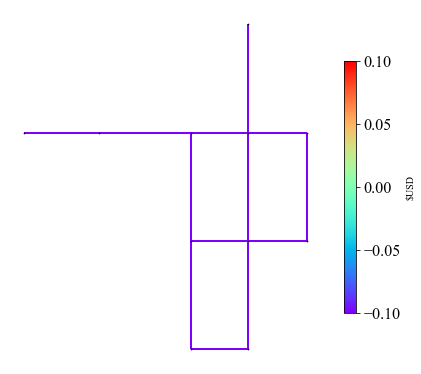

In [523]:
edge_value=Costt
c_color=plt.cm.rainbow
G = nx.parse_edgelist(d, nodetype = int, data=(('id',int),))
nx.draw(G,pos,node_size=0.5,edge_color =edge_value, node_color='k',width=2,with_labels=False,edge_cmap = c_color)
sm = plt.cm.ScalarMappable(norm=plt.Normalize(edge_value.min(), edge_value.max()),cmap = c_color)
plt.colorbar(sm,label='$USD',shrink=.7)
# plt.scatter(ex, ey, s=500, c='r', marker='*', zorder=2)
# plt.savefig('Fairfield_Cost.png', dpi = 600,bbox_inches='tight')

In [524]:
# nx.shortest_path(G, 1721);

In [525]:
# pd.Series(nx.single_source_shortest_path(G,1721));

### Isolated Graph after removing damaged components

In [526]:
n_link=nw[nw.MA==0]

In [527]:
pp = []
for index, row in n_link.iterrows():
    stt = str(row['start_node'])+str(row['end_node']).rjust(10)
    pp.append(stt)

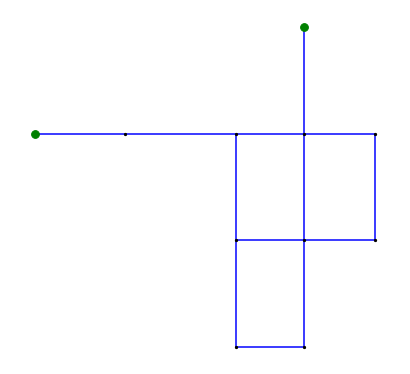

In [528]:
# draw Graph of water network
G = nx.parse_edgelist(pp,nodetype=int)
nx.draw(G,pos,node_size=5, node_color='k', edge_color='b',width=1.5)
nx.draw(G3,pos3,node_size=60,node_color='g',with_labels=False)
plt.savefig('Isolated_Fairfield.png', dpi = 600,bbox_inches='tight')

In [529]:
nx.number_of_isolates(G)

0

### Plot Networks

In [530]:
# read node and link positions
node = pd.read_csv('node_deg_fairfield.csv')
# link = pd.read_csv('edge classify.csv')
link = pd.read_csv('pipe_fairfield.csv')

In [531]:
import os
import folium
from folium.plugins.measure_control import MeasureControl

In [532]:
link.head(1)

,start_node,end_node,type,PipID,Length,dia,M_type,Material,soil_type,age
0,106,107,1,119,570,24,CI,CIP,L,1920


In [533]:
# data1 and data2 should be node and link, respectively
def Coord(data1,data2):  
    pos={}
    ll=[]
    for index, row in data2.iterrows():
        sp=data1[data1.id==row['start_node']]
        start_x, start_y = (list(sp.x),list(sp.y))
        ep=data1[data1.id==row['end_node']]
        end_x,end_y=(list(ep.x),list(ep.y))
        pos[int(row['PipID'])]=start_y+start_x,end_y+end_x
        ll=data2['Length']
    return pos, ll

In [534]:
posL,ll=Coord(node,link)

In [535]:
coordinatesL=posL.values()

In [536]:
coL=list(coordinatesL)

In [537]:
# Create the map and add the line
m = folium.Map(location=[38.28409957,-122.0654925], zoom_start=14)
# folium.TileLayer('cartodbpositron').add_to(m)

# linear = cm.LinearColormap(
#     ['green', 'yellow', 'red'],
#     vmin=3, vmax=10)

# o=folium
folium.PolyLine(coL, color='blue',weight=2, opacity=0.7).add_to(m)
# folium.LayerControl().add_to(m)

m;

In [538]:
bc_node=nx.betweenness_centrality(G)
bc_node;

In [539]:
bc_edge=nx.edge_betweenness_centrality(G)
bc_edge;

In [540]:
r, pga, pgv, pos = Distance.com_pga_dist(node,ex,ey,M)

In [541]:
link_attribute=bc_edge
link_width=2
link_range=[0,1]
link_cmap_bins='cut'
link_cmap=['cornflowerblue', 'forestgreen', 'gold', 'firebrick']

In [542]:
link.head(1)

,start_node,end_node,type,PipID,Length,dia,M_type,Material,soil_type,age
0,106,107,1,119,570,24,CI,CIP,L,1920


In [543]:
node.head()

,id,x,y,type
0,106,-122.078409,38.278968,1
1,107,-122.076287,38.278506,1
2,108,-122.076489,38.277904,1
3,109,-122.075826,38.278338,1
4,111,-122.076030,38.277819,1


In [544]:
def Loc(data):  
    pos={}
    for index, row in data.iterrows():
        loc = (row['y'], row['x'])
        pos[int(row['id'])]=loc

    return pos

In [545]:
posN=Loc(node)

In [546]:
# coordinates=pos.values()
# co=list(coordinates)
# list(coordinates);

In [547]:
link_v=need.MA
node_v=n_out.node_pga

In [548]:
def plot_leaflet_network(G, node_attribute=None, link_attribute=None, 
               node_attribute_name = 'Value', 
               link_attribute_name = 'Value',
               node_size=2, node_range=[None,None], 
               node_cmap=['cornflowerblue', 'forestgreen', 'gold', 'firebrick'], 
               node_cmap_bins = 'cut', node_labels=True,
               link_width=5, link_range=[None,None], 
               link_cmap=['cornflowerblue', 'forestgreen', 'gold', 'firebrick'], 
               link_cmap_bins='cut', link_labels=True,
               add_legend=False, round_ndigits=2, zoom_start=12, 
               add_to_node_popup=None, add_to_link_popup=None,
               filename='leaflet_network.html'):
    """
    G:network model
    """
    
    if folium is None:
        raise ImportError('folium is required')
    
    if node_attribute is not None:
        if isinstance(node_attribute, list):
            node_cmap=['red']
        node_attribute = node_v
        node_attribute = pd.Series(node_attribute)
        if node_range[0] is not None:
            node_attribute[node_attribute < node_range[0]] = node_range[0]
        if node_range[1] is not None:
            node_attribute[node_attribute > node_range[1]] = node_range[1]
        if node_cmap_bins == 'cut':
            node_colors, node_bins = pd.cut(node_attribute, len(node_cmap), 
                                                labels=node_cmap, retbins =True)
        elif node_cmap_bins == 'qcut':
            node_colors, node_bins = pd.qcut(node_attribute, len(node_cmap), 
                                                 labels=node_cmap, retbins =True)
            
    if link_attribute is not None:
        if isinstance(link_attribute, list):
            link_cmap=['red']
        link_attribute = link_v
        link_attribute = pd.Series(link_attribute)
        if link_range[0] is not None:
            link_attribute[link_attribute < link_range[0]] = link_range[0]
        if link_range[1] is not None:
            link_attribute[link_attribute > link_range[1]] = link_range[1]
        if link_cmap_bins == 'cut':
            link_colors, link_bins  = pd.cut(link_attribute, len(link_cmap), 
                                             labels=link_cmap, retbins =True)
        elif link_cmap_bins == 'qcut':
            link_colors, link_bins  = pd.qcut(link_attribute, len(link_cmap), 
                                              labels=link_cmap, retbins =True)
            
    center = pd.DataFrame(pos).mean(axis=1)
    m = folium.Map(location=[center.iloc[1], center.iloc[0]], zoom_start=14, tiles='Stamen Terrain')
    folium.TileLayer('cartodbpositron').add_to(m)
    
    if node_size > 0:
        for index, row in node.iterrows():    
            loc = (row['y'], row['x'])
            radius = node_size
            color = 'black'       
            if node_attribute is not None:
                if index in node_attribute:
                    color = node_colors[index]
                else:
                    radius = 0.1
            folium.CircleMarker(loc, color=color, fill=True,fill_color=color, radius=2, fill_opacity=0.7, opacity=0.7).add_to(m)
            
    if link_width > 0:
        for index, row in link.iterrows():
            sp=node[node.id==row['start_node']]
            start_x,start_y=(list(sp.x),list(sp.y))
            ep=node[node.id==row['end_node']]
            end_x,end_y=(list(ep.x),list(ep.y))
            posK=start_y+start_x,end_y+end_x
            weight = link_width
            color='black'           
            if link_attribute is not None:
                if index in link_attribute:
                    color = link_colors[index]
                else:
                    weight = 0.5
            
            folium.PolyLine(posK, color=color,fill=True,fill_color=color,weight=5, opacity=0.7).add_to(m)
#             folium.Marker(location=[center.iloc[1], center.iloc[0]],popup='RKM',icon=folium.Icon(color='red')).add_to(m)   
    
    folium.LayerControl().add_to(m)
    
    m.save(filename)
    m

In [549]:
plot_leaflet_network(G,node_attribute=node_v,link_attribute=link_v,link_width=2,filename='N_P.html')

In [550]:
# Stamen Terrain
# Stamen Toner

In [551]:
link_v=P_leak
node_v=n_out.node_pga

In [552]:
node_size=2
node_attribute=node_v
link_attribute=link_v
node_range=[None,None]
node_cmap_bins = 'cut'
link_cmap_bins='cut'
node_cmap=['cornflowerblue', 'forestgreen', 'gold', 'firebrick'] 
link_cmap=['cornflowerblue', 'forestgreen', 'gold', 'firebrick']

In [553]:
    if node_attribute is not None:
        if isinstance(node_attribute, list):
            node_cmap=['red']
        node_attribute = node_v
        node_attribute = pd.Series(node_attribute)
        if node_range[0] is not None:
            node_attribute[node_attribute < node_range[0]] = node_range[0]
        if node_range[1] is not None:
            node_attribute[node_attribute > node_range[1]] = node_range[1]
        if node_cmap_bins == 'cut':
            node_colors, node_bins = pd.cut(node_attribute, len(node_cmap), 
                                                labels=node_cmap, retbins =True)
        elif node_cmap_bins == 'qcut':
            node_colors, node_bins = pd.qcut(node_attribute, len(node_cmap), 
                                                 labels=node_cmap, retbins =True)
            
    if link_attribute is not None:
        if isinstance(link_attribute, list):
            link_cmap=['red']
        link_attribute = link_v
        link_attribute = pd.Series(link_attribute)
        if link_range[0] is not None:
            link_attribute[link_attribute < link_range[0]] = link_range[0]
        if link_range[1] is not None:
            link_attribute[link_attribute > link_range[1]] = link_range[1]
        if link_cmap_bins == 'cut':
            link_colors, link_bins  = pd.cut(link_attribute, len(link_cmap), 
                                             labels=link_cmap, retbins =True)
        elif link_cmap_bins == 'qcut':
            link_colors, link_bins  = pd.qcut(link_attribute, len(link_cmap), 
                                              labels=link_cmap, retbins =True)
            
    center = pd.DataFrame(pos).mean(axis=1)
    m = folium.Map(location=[center.iloc[1], center.iloc[0]], zoom_start=14)
    folium.TileLayer('cartodbpositron').add_to(m)
    folium.TileLayer('Stamen Toner').add_to(m)
    folium.TileLayer('openstreetmap').add_to(m)
    folium.TileLayer('stamenterrain').add_to(m)
    folium.TileLayer('stamenwatercolor').add_to(m)
    folium.TileLayer('cartodbdark_matter').add_to(m)

    
    if node_size > 0:
        for index, row in node.iterrows():    
            loc = (row['y'], row['x'])
            radius = node_size
            color = 'black'       
            if node_attribute is not None:
                if index in node_attribute:
                    color = node_colors[index]
                else:
                    radius = 0.1
            folium.CircleMarker(loc, color=color, fill=True,fill_color=color, radius=1, fill_opacity=0.7, opacity=0.7).add_to(m)
            
    if link_width > 0:
        for index, row in link.iterrows():
            sp=node[node.id==row['start_node']]
            start_x,start_y=(list(sp.x),list(sp.y))
            ep=node[node.id==row['end_node']]
            end_x,end_y=(list(ep.x),list(ep.y))
            posK=start_y+start_x,end_y+end_x
            weight = link_width
            color='black'           
            if link_attribute is not None:
                if index in link_attribute:
                    color = link_colors[index]
                else:
                    weight = 0.5
            bins = list(link_v.quantile([0, 0.25, 0.5, 0.75, 1]))

            folium.PolyLine(posK, color=color,fill=True,fill_color=color,weight=3, opacity=0.7).add_to(m)
#             folium.Marker(location=[center.iloc[1], center.iloc[0]],popup='RKM',icon=folium.Icon(color='red')).add_to(m)   
    folium.LayerControl().add_to(m)
    
    m